In [1]:
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from pyparsing import lineStart

from src import ttl, io
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

In [2]:
# set main data path
base_data_path = "/Volumes/AhmedLab/princess/data"
exp = 101

# set experiment file path
raw_path = glob.glob(os.path.join(base_data_path, 'raw', f'*{exp}'))[0]
csv_path = glob.glob(os.path.join(raw_path, '*.csv'))[0]
xml_path = glob.glob(os.path.join(raw_path, '*.xml'))[0]

In [3]:
def extract_xml_timestamps(xml_file_path):
    """
    Pull timestamp information from experiment XML file
    Inputs:
        XML file
    Outputs:
        array of scope timestamp data (ms) - relative to the first 2p frame
        time zero for scope
        time zero for camera
    """
    tree = ET.parse(xml_file_path)
    root = tree.getroot()

    xml_timestamps = []
    slice_index = []

    for element in root.iter("Frame"):
        timestamp = float(element.attrib['absoluteTime'])   # doublecheck absolute or relative time
        # convert from seconds to milliseconds
        # timestamp = timestamp/1000

        xml_timestamps.append(timestamp)
        slice_index.append(int(element.attrib['index']))
    time_zero = xml_timestamps[0]
    # adjust timestamps relative to starting time
    xml_timestamps = np.subtract(xml_timestamps, time_zero)
    # align xml timestamps to ttl signals
    # xml_timestamps = np.add(xml_timestamps, time_shift)

    # checks that complete volumes are being recorded
    # the number of frames should be divisible by the number of slices
    # assert len(xml_timestamps)%max(slice_index) == 0

    return xml_timestamps

def extract_camera_timestamps(csv_file_path):
    """
    Pull timestamp information from experiment CSV file
    Inputs:
        CSV file
    Outputs:
        array of camera and scope timestamp data (ms)
    """
    csv_data = pd.read_csv(csv_file_path)
    csv_data.columns = csv_data.columns.str.strip()
    column_means = np.floor(csv_data.mean())
    for idx, column_mean in enumerate(column_means):
        if column_mean == 0:
            scope_idx = idx
        elif 0 < column_mean < 5:
            side_camera_idx = idx
    if len(csv_data.columns) == 3:
        data = csv_data.rename(columns={f'{csv_data.columns[scope_idx]}': 'Scope', f'{csv_data.columns[side_camera_idx]}': 'Side Camera'})
    return data

In [5]:
xml_timeseries = extract_xml_timestamps(xml_path)
ttl_csv = ttl.read_csv(csv_path)
scope_timestamps = ttl.extract_2p_relative_timestamps(ttl_csv)
camera_timestamps = ttl.extract_camera_relative_timestamps(ttl_csv)
scope_framerate = ttl.get_frame_rate(pd.Series(scope_timestamps))
camera_framerate = ttl.get_frame_rate(pd.Series(camera_timestamps))

# Units
- xml - seconds
- csv - ms - converted to seconds for visualization

In [42]:
scope_timestamps = scope_timestamps/1000

Text(0.5, 0, 'time(s)')

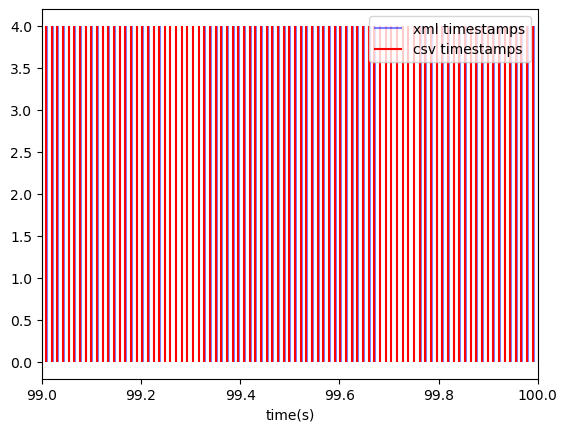

In [36]:
plt.vlines(xml_timeseries, 0, 4, colors='blue', alpha=0.5, label='xml timestamps')
plt.vlines(scope_timestamps, 0, 4, colors='red', label='csv timestamps')
plt.legend()
plt.xlim(99, 100)
plt.xlabel('time(s)')

In [43]:
scope_timestamps[0]
tests = xml_timeseries
test_shift = np.add(tests, scope_timestamps[0])

In [44]:
print(scope_timestamps[0], tests[0])

0.0001 0.0


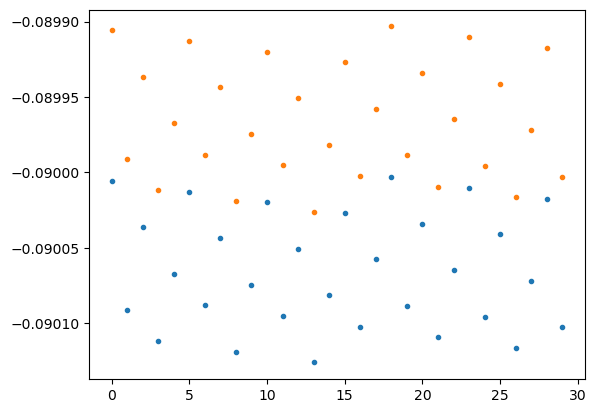

In [35]:
diffs = tests[-30:] - scope_timestamps[-30:]
diffs2 = test_shift[-30:]  - scope_timestamps[-30:]
plt.plot(diffs, marker='.', linestyle = 'none')
plt.plot(diffs2, marker='.', linestyle = 'none')

(0.0, 100.0)

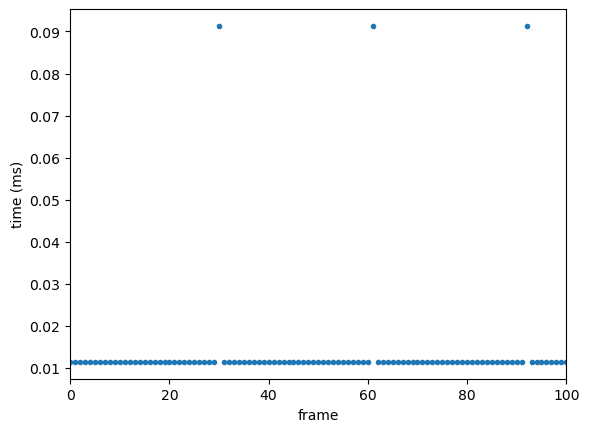

In [51]:
# flyback time
frame_diffs = np.diff(xml_timeseries)
plt.plot(frame_diffs, marker='.', linestyle = 'none')
plt.ylabel('time (ms)')
plt.xlabel('frame')
plt.xlim(0,100)

In [60]:
flyback_times = []
for val in frame_diffs:
    if val > .02:
        flyback_times.append(val)
print(np.mean(flyback_times)*1000)

91.31664800000027


In [78]:
vol_blocks = np.reshape(xml_timeseries, (-1,31))
print(vol_blocks.shape)

volume_times = []
for block in vol_blocks:
    # print(block[0], block[-1])
    vol_time = block[0]-block[-1]
    volume_times.append(-vol_time)
print(np.mean(volume_times)*1000)

(2767, 31)
342.4374299999996


In [81]:
volume_timing = np.mean(volume_times) + np.mean(flyback_times)
rate = 1/volume_timing
rate

np.float64(2.3054538290703985)